In [15]:
from hybrid_surr import plot_hyb
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import numpy as np
import arviz as az
#from io import BytesIO
from hybrid_surr import plot_funcs
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [8]:
import arviz as az
import numpy as np
import pandas as pd

# 1. Загружаем DataFrame
df = pd.read_csv("pcd.csv")
df_sorted = df.sort_values(by=["incidence_dim_0"])
# 3. Вытаскиваем значения в обычный 1D массив NumPy
incidence_vector = df_sorted["incidence"].values
# 4. Создаем idata, явно указывая группу predictions_constant_data
new_idata_pcd = az.from_dict(
    predictions_constant_data={"incidence": incidence_vector}
)
new_idata_pcd

Inference data with groups:
	> predictions_constant_data

In [9]:
df = pd.read_csv("p.csv")
df_sorted = df.sort_values(by=["chain", "draw", "sim_dim_0"])

# 3. Считаем уникальные размеры, чтобы автоматически определить форму
n_chains = df_sorted["chain"].nunique()
n_draws = df_sorted["draw"].nunique()
n_elements = df_sorted["sim_dim_0"].nunique()

# 4. Вытаскиваем колонку со значениями и делаем reshape в 3D
# Итоговая форма: (цепи, шаги, размер_вектора)
sim_matrix = df_sorted["sim"].values.reshape(n_chains, n_draws, n_elements)

# 5. Создаем новый idata (например, в группу posterior или posterior_predictive)
new_idata = az.from_dict(predictions={"sim": sim_matrix})
new_idata

Inference data with groups:
	> predictions

In [7]:
idata = az.from_netcdf("hybrid_surr/calibr/ba_hyb_600_3_pred_27_eps_500.nc")
idata

Inference data with groups:
	> posterior
	> predictions
	> sample_stats
	> observed_data
	> constant_data
	> predictions_constant_data

In [10]:
# Удаляем старые группы, чтобы избежать конфликта дубликатов
if "predictions" in idata.groups():
    del idata.predictions
if "predictions_constant_data" in idata.groups():
    del idata.predictions_constant_data

# Теперь extend отработает чисто
idata.extend(new_idata)
idata.extend(new_idata_pcd)
idata

Inference data with groups:
	> posterior
	> predictions
	> sample_stats
	> observed_data
	> constant_data
	> predictions_constant_data

In [12]:
idatap = idata.copy()
# for string
idatap.sample_stats['beta'] = idatap.sample_stats['beta'].astype(str)
idatap.to_netcdf(f"hybrid_surr/calibr/ba_hyb_{600}_{3}_pred_27_eps_500_p100.nc")

'hybrid_surr/calibr/ba_hyb_600_3_pred_27_eps_500_p100.nc'

## hybrid

In [64]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']
methods = ['last value','expanding mean last value',
            'median beta', 'regression beta', 'lstm' ]
new_labels = ['last_value', 'expanding_mean_last_value', 
            'median_beta',  'regression_beta', 'lstm_day_E_previous_I'
             ]

sigma=0.3
gamma=0.2
perc_switch=0.01
stoch=10

seed_dirs="../long_sw_100000_fin/"
#seed_dirs="../new_ba_100000/"
sw = pd.read_csv('hybrid_surr/aux_hyb/test_files.csv').values

In [63]:
!ls 'hyrbid_surr/aux_hyb/

'pwd' is not recognized as an internal or external command,
operable program or batch file.


path:  hybrid_surr/aux_hyb/ba100k_regression_bt.joblib
was there? 51
5 1000.0 fraq_people 0.01
was there? 46
5 1000.0 fraq_people 0.01
path:  hybrid_surr/aux_hyb/ba100k_lstm_4_001_s10
was there? 51
5 1000.0 fraq_people 0.01
was there? 46
5 1000.0 fraq_people 0.01
CPU times: total: 2.03 s
Wall time: 1.77 s


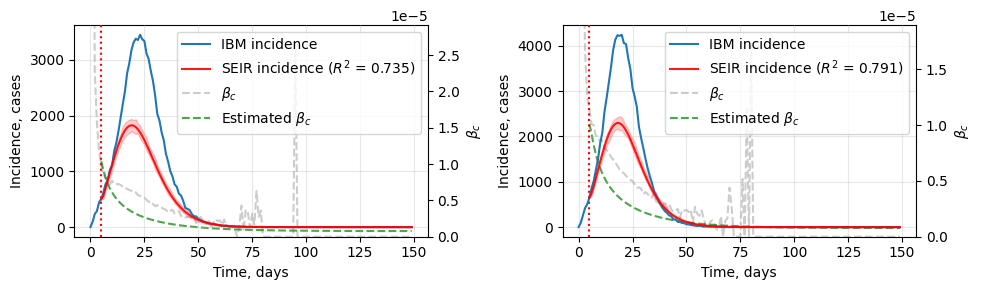

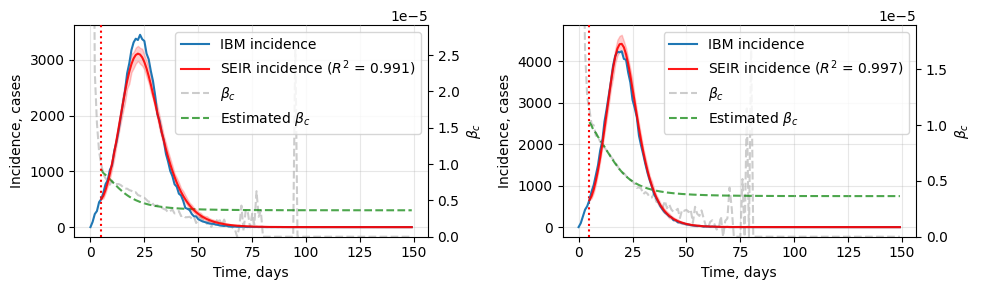

In [71]:
%%time
k = 200
sw = pd.read_csv('hybrid_surr/aux_hyb/ba_test_files.csv').values
plot_hyb.apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10][k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100, 
                m_folder='hybrid_surr/aux_hyb/',
             suff_m='ba100k', suff='ba100k_10')

path:  hybrid_surr/aux_hyb/sw100k_regression_bt.joblib
[Errno 2] No such file or directory: '../long_sw_100000_fin/p_0.1_0.3_0.2_0.0001_0.79_seed_0.csv'
path:  hybrid_surr/aux_hyb/sw100k_lstm_4_001_s10
[Errno 2] No such file or directory: '../long_sw_100000_fin/p_0.1_0.3_0.2_0.0001_0.79_seed_0.csv'
CPU times: total: 31.2 ms
Wall time: 35 ms


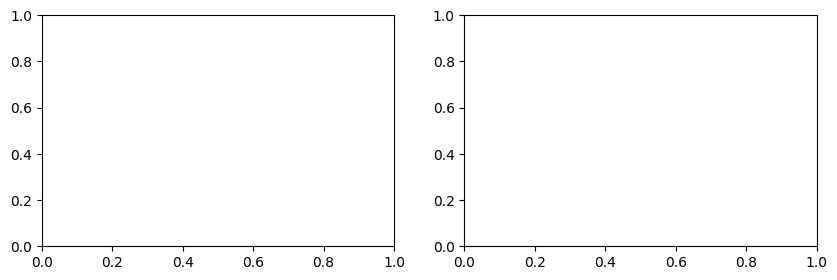

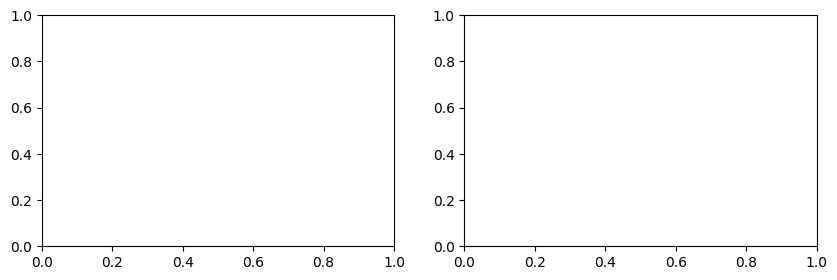

In [69]:
%%time
k = 20
sw = pd.read_csv('hybrid_surr/aux_hyb/test_files.csv').values
plot_hyb.apply_methods(seed_dirs="../long_sw_100000_fin/",
              seed_numbers=sw[::10][k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01, stoch=100, 
                m_folder='hybrid_surr/aux_hyb/',
             suff_m='sw100k', suff='sw100k_10')

was there? 0
4 1000.0 fraq_people 0.01


PermissionError: [Errno 13] Permission denied: 'hybrid_surr/aux_hyb/'

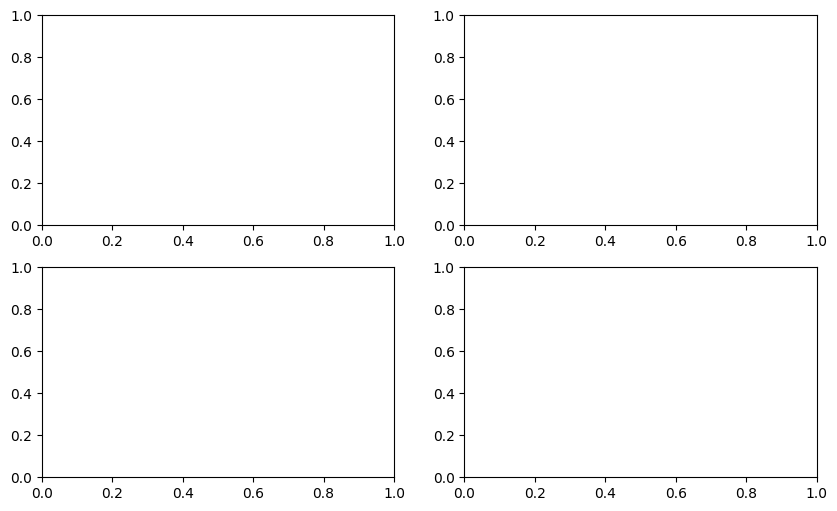

In [49]:
types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']
methods = ['last value','expanding mean last value',
           'median beta','regression beta', 'lstm']
new_labels = ['last_value', 'expanding_mean_last_value', 
            'median_beta', 'regression_beta', 
              'lstm_day_E_previous_I']
suff_m='sw100k'
suff='sw100k'
topology =suff_m[:2] 
beta_pred = 'median'
m_folder='hybrid_surr/aux_hyb/'

if 'median' in beta_pred:
    model_path = f'{m_folder}{suff_m}_median_beta.csv'
elif 'regression beta' in beta_pred:
    model_path = f'{m_folder}{suff_m}_regression_bt.joblib'
elif 'lstm' in beta_pred:
    model_path = f'{m_folder}{suff_m}_lstm_4_001_s10'   
else:
    model_path=''
                
k = 145
fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax = ax.flatten()

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-2], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[0]], model_path='hybrid_surr/aux_hyb/',
                perc_switch=perc_switch,
                is_filename=True,on_incidence=True,
                switch_on_incidence=False)
ax[0].text(-0.1, 1.1, 'a)',
           transform=ax[0].transAxes, size=15)

plot_hyb.main_f(I_prediction_method='seir', count_stoch_line=100, 
                beta_prediction_method=methods[-1], 
                type_start_day=types_start_day[0], 
                seed_numbers=sw[::10][k:k+1], show_fig_flag=True,
                seed_dirs=seed_dirs, sigma=sigma, gamma=gamma, 
                ax=[ax[1]], model_path='hybrid_surr/aux_hyb/',
                perc_switch=perc_switch,
                is_filename=True,on_incidence=True,
                switch_on_incidence=False)
ax[1].text(-0.1, 1.1, 'b)',
           transform=ax[1].transAxes, size=15)


plt.tight_layout()

## calibrating

In [13]:

'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
folder='hybrid_surr/calibr/'

file=folder+'data_ba_100000.csv'
d = pd.read_csv(file, index_col=0)#.iloc[::10]
if 'init_rec_frac' in d.columns:
    d.rename(columns={'init_rec_frac':'alpha'}, inplace=True)
d.drop(columns=['gamma','delta','init_inf_frac'], inplace=True)
s = 150



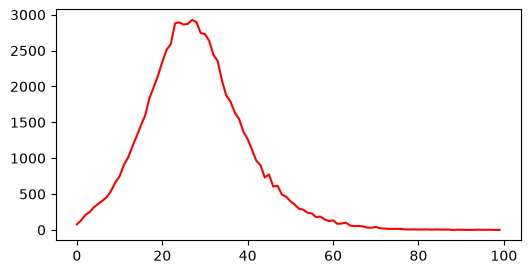

In [16]:
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv(folder+'incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)
'''
i = 0
results=[]
for beta in beta_arr:
    beta = round(beta,2)
    for alpha in alpha_arr:
        alpha = round(alpha,2)
        #print(chosen.iloc[:,:2].values, beta, alpha)


        if (beta==true_tau)&(alpha==true_alpha):
            incidence = d.iloc[i*10:i*10+10,2:].values#.mean()
            for i in range(10):
                plt.plot(incidence[i][:100], color='tab:blue',
                        alpha=0.4, label='')
        i+=1
'''
plt.plot(observed_data,color='red')

In [17]:
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

#draws = 600
#chains = 3
top='ba'
koeff=1
shift=0
network_params=[with_switch,num_runs,frac,gamma,
                delta,n_nodes,top,koeff,shift]

idata = az.from_netcdf(folder+f"ba_hyb_{600}_{3}_s3_r3.nc")


0.149405969205227 0.8945333434284561
shift: 0
samples with r2>= 0.7 : 0.89
samples with r2>= 0.75 : 0.82
samples with r2>= 0.8 : 0.73
samples with r2>= 0.85 : 0.63
samples with r2>= 0.9 : 0.49
r2 mean: 0.857
running hyb:  0
CPU times: total: 7.84 s
Wall time: 8.37 s


(0.149405969205227, 0.8945333434284561)

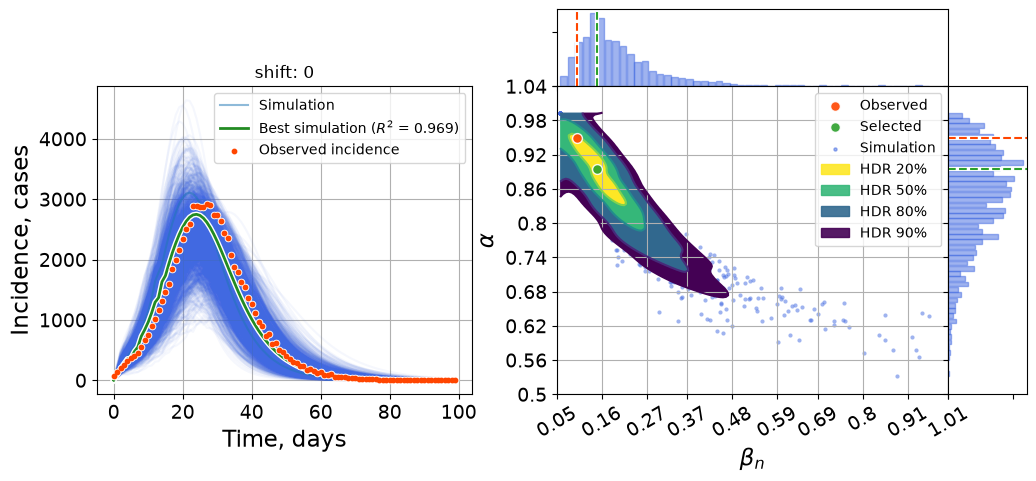

In [17]:
%%time

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params,
                     n_hyb_runs=1)
#plt.savefig(f'results/ba_hybrid.pdf', format='pdf', bbox_inches='tight')
#png.getvalue()


0.1615659924746181 0.8760162288835825
sim plot time 0.3449575901031494
[1]

0.149405969205227 0.8945333434284561
sim plot time 0.3246293067932129
[1]

0.1512882948042508 0.8855652941232481
sim plot time 3.2934303283691406
[0]
CPU times: total: 2min 26s
Wall time: 2min 27s


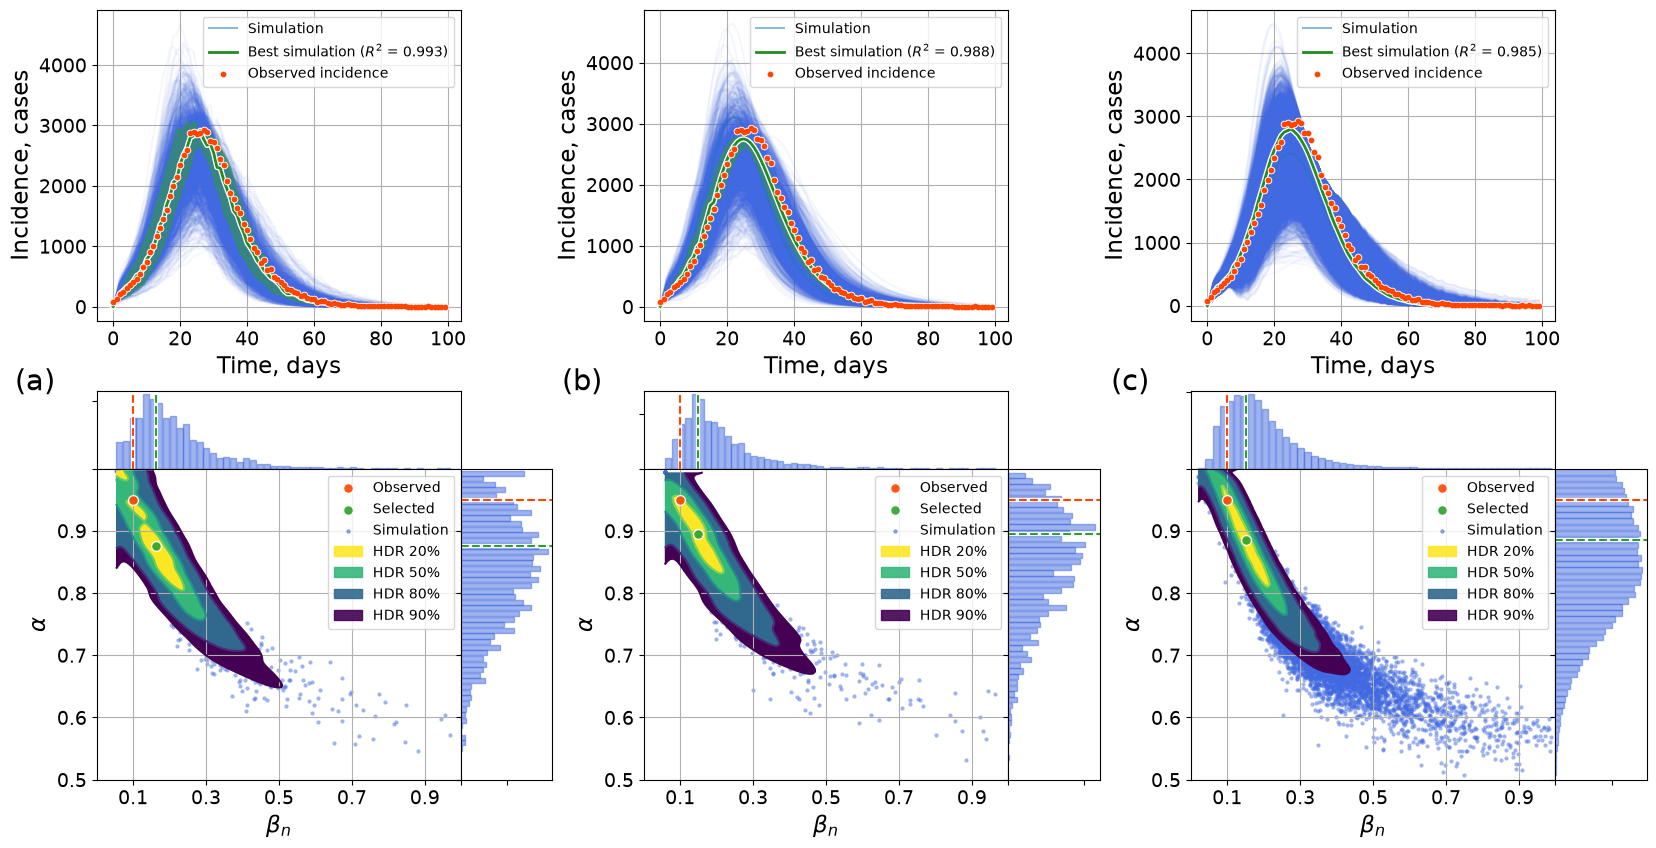

In [5]:
%%time
alphabet = 'abcdefghijklmnopqrstuvwxyz'
labels = ['('+alphabet[index] + ')' for index in range(len(alphabet))]

fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
top='ba'
idata14 = az.from_netcdf(folder+f"ba_net_600_3.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_600_3_s3_r3.nc")
idata0 = az.from_netcdf(folder+f"ba_surr.nc").rename({"beta": "tau"})


with_switch=np.array(False) 
with_df=np.array(False) 
n_hyb_runs=10
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]


for gs_0i, gs_1i, idata_i,idx  in zip([gs00,gs01,gs02],
                                 [gs10,gs11,gs12],
                         [idata14,idata7,idata0],
                                     np.arange(3)):
    
    if idx==1:
        frac=[0.05]
        with_switch=np.array(True) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]
    elif idx == 2:
        num_runs = [0]
        frac=[1]
        with_switch=np.array(False) 
        network_params=[with_switch,num_runs,frac,gamma,
                        delta,n_nodes,top,koeff,shift]

    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    beta_mode, alpha_mode = plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=False,
                          n_hyb_runs=n_hyb_runs,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])
    fontsize=14
    ax_curves.annotate(labels[idx], xy=(0, 0), xycoords='axes fraction',
                           xytext=(-30, -50), textcoords='offset points',
                           fontsize=1.5*fontsize, ha='right', va='baseline')
    
#plt.savefig(f'results/ba_all_appr.pdf', bbox_inches='tight')
#plt.savefig(f'results/ba_all_appr.png', bbox_inches='tight')


0.3319899334904737 0.7018917114413784
sim plot time 0.6844902038574219
[1]

0.3124724971578574 0.7423251112435076
sim plot time 0.7554314136505127
[1]

0.09926934980124971 0.9556286086094852
sim plot time 0.2912616729736328
[1]


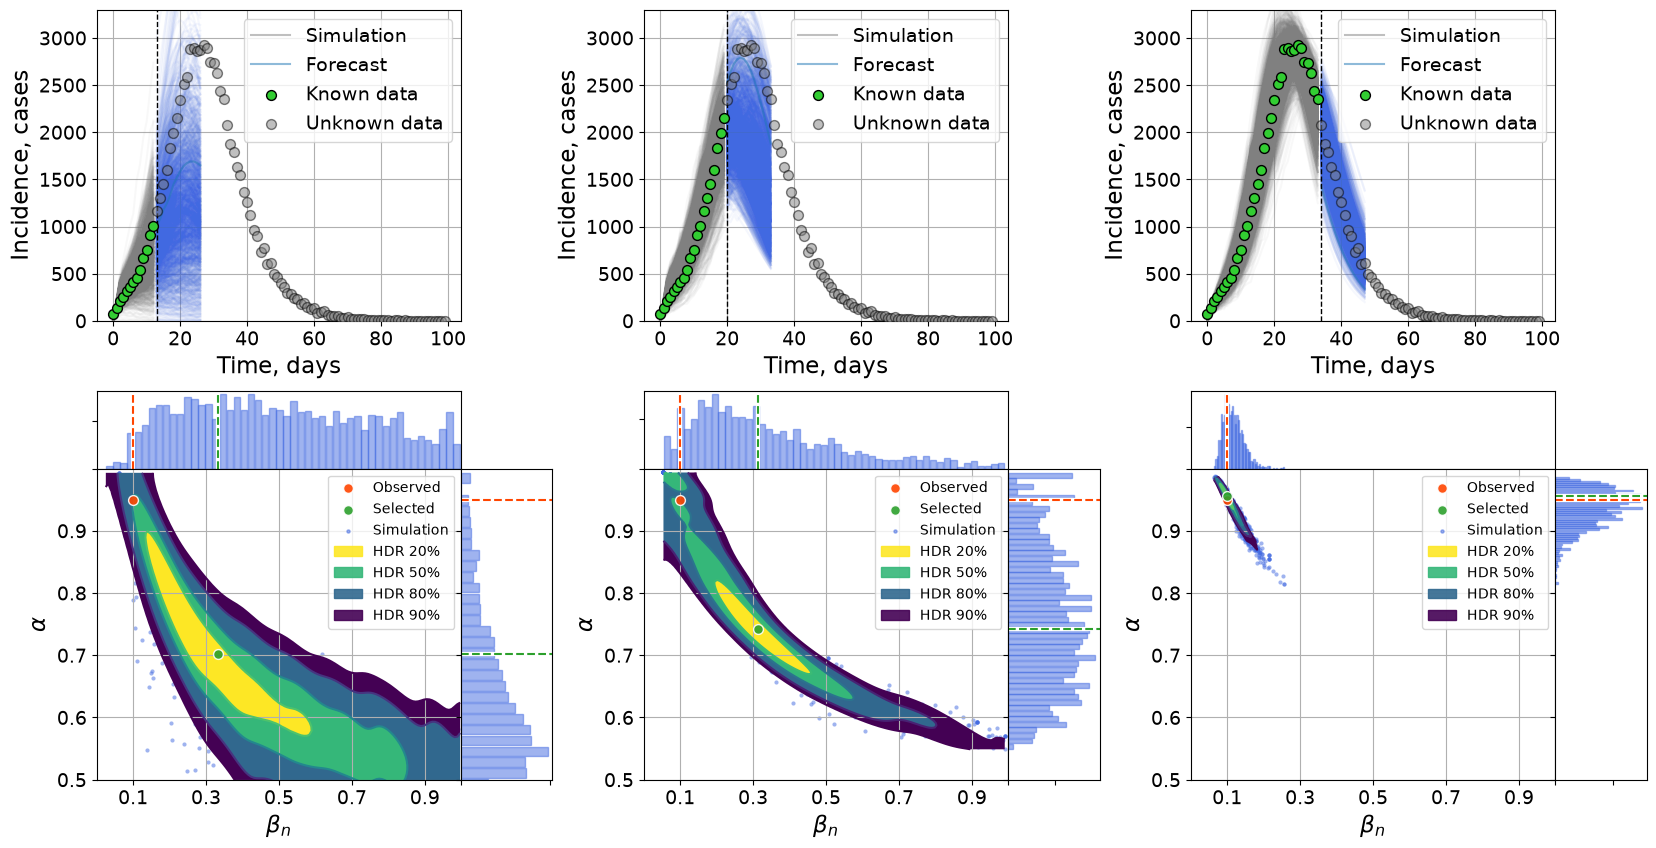

In [18]:
fig = plt.figure(figsize=(20,10))
# adding gridspec
gs = fig.add_gridspec(2, 3, hspace=0.2, width_ratios=[1,1,1],
                     height_ratios=[1,1.25])

# curves subplots
gs00 = gs[0,0].subgridspec(1, 2, width_ratios=[4, 1],
                           wspace=0.)
gs01 = gs[0,1].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)
gs02 = gs[0,2].subgridspec(1, 2, width_ratios=[4, 1],
                          wspace=0.)

# ufo subplots
gs10 = gs[1,0].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs11 = gs[1,1].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
gs12 = gs[1,2].subgridspec(2, 2, wspace=0, hspace=0.,
                        width_ratios=[4, 1],
                        height_ratios=[1, 4])
with_switch=np.array(False) 
with_df=np.array(False) 
n_hyb_runs=10
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000
network_params=[with_switch,num_runs,frac,
                gamma,delta,n_nodes,top,koeff,shift]

idata14 = az.from_netcdf(folder+f"ba_hyb_600_3_pred_14_eps_500.nc")
idata7 = az.from_netcdf(folder+f"ba_hyb_600_3_pred_7_eps_500.nc")
idata0 = az.from_netcdf(folder+f"ba_hyb_600_3_pred_27_eps_500_p100.nc")
k=3
for gs_0i, gs_1i, idata_i in zip([gs00,gs01,gs02][:k],
                                 [gs10,gs11,gs12][:k],
                         [idata14,idata7,idata0][:k]):
    
    ax_curves = fig.add_subplot(gs_0i[0])

    ax_up = fig.add_subplot(gs_1i[0])
    ax_scatter = fig.add_subplot(gs_1i[2], sharex=ax_up)
    ax_right = fig.add_subplot(gs_1i[3], sharey=ax_scatter)

    plot_funcs.plot_calib(observed_data, idata_i, 
                   true_tau, true_alpha, 
                   network_params, pred=True,
                         ax_curves=[ax_curves],
                         ax_kde=[ax_up,ax_scatter,ax_right])

#plt.savefig(f'results/ba_pred_eps1000.pdf', format='pdf', bbox_inches='tight')

In [44]:
az.from_netcdf("hybrid_surr/calibr/ba_hyb_600_3_pred_27_eps_500.nc")

OSError: Can't synchronously read data (filter returned failure during read)